
### 🌍 EQUIPO 4: Análisis de Datos Demográficos aplicando los métodos estadísticos de correlación y regresión lineal. 

---

#### **1. 🎯 El Reto y Origen de los Datos**
El foco de nuestra investigación es la correlacion-regresion, (dirección e intensidad). La Regresión lineal simple.
Interpretación básica de R2 y error. 
Nos centraremos en las variables *Población* y *Área* para nuestros cálculos.

#### **2. 📊 Objetivo Estadístico**

Nuestra investigación consiste en determinar si existe una relación matemática predecible entre la extensión territorial de un país (Área) y el número de habitantes que alberga (Población).

Para ello, aplicaremos dos herramientas fundamentales de la estadística:

#### *1. Correlación de Pearson* 

#### *2. Regresión Lineal Simple* 

### **3. Justificación**

Comprender la correlación entre área y población es vital para el análisis de la *densidad demográfica*. 
Este estudio nos permitirá identificar **"outliers"** o casos atípicos.

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Estilo configurado! 🎨")

Estilo configurado! 🎨


### 🗺 Consumo de la API y DataFrame

---

In [60]:
import requests
import pandas as pd
import numpy as np

url = "https://restcountries.com/v3.1/all?fields=name,area,population,region,gini"
response = requests.get(url)
data = response.json()
rows = []
for country in data:
    rows.append({
        "country": country.get("name", {}).get("common"),
        "region": country.get("region", 'N/A'),
        "population": country.get("population", 0),
        "area": country.get("area"),
        })
df = pd.DataFrame(rows)

# Limpieza básica
df = df.dropna(subset=["population", "area"])
#df = df[df["area"] > 0]
#df = df[df["population"] > 0]
#df["area"] = df["area"].astype(int)


# Variable derivada útil: densidad 
df["density"] = (df["population"] / df["area"]).round(2)

# Creamos una variable que genere una lista aleatoria de 30 países que usaremos como muestra para nuestros cálculos
df_muestra = df.sample(100, random_state=42).copy()

# Ordenamos la muestra por la columna 'region'

df_muestra_ordenada = df_muestra.sort_values(by="region")
print(f'Muestra  aleatoria de paises agrupados por región: ')

# Mostramos los 100 países (o los que tenga la muestra)

display(df_muestra_ordenada.rename(columns={"area": "area (km²)","population": "population (hab)"}))


Muestra  aleatoria de paises agrupados por región: 


,country,region,population (hab),area (km²),density
38,Mali,Africa,22395489,1240192.0,18.06
42,Tanzania,Africa,68153004,947303.0,71.94
186,British Indian Ocean Territory,Africa,0,60.0,0.00
126,Zambia,Africa,19693423,752612.0,26.17
29,Egypt,Africa,107271260,1002450.0,107.01
...,...,...,...,...,...
140,Australia,Oceania,27536874,7692024.0,3.58
96,Samoa,Oceania,205557,2842.0,72.33
60,French Polynesia,Oceania,279500,4167.0,67.07
216,Fiji,Oceania,900869,18272.0,49.30


## "outliers": población

In [61]:
paises_menos_200 = df[df["population"] < 50]
print(f'Paises con una población menor de 50 km2')
display(paises_menos_200)

Paises con una población menor de 50 km2


,country,region,population,area,density
16,Bouvet Island,Antarctic,0,49.0,0.00
48,South Georgia,Antarctic,0,3903.0,0.00
50,United States Minor Outlying Islands,Americas,0,34.2,0.00
152,Heard Island and McDonald Islands,Antarctic,0,412.0,0.00
159,Pitcairn Islands,Oceania,35,47.0,0.74
186,British Indian Ocean Territory,Africa,0,60.0,0.00


## "outliers": área

In [62]:
paises_area = df[df["area"] < 10]
print(f'Paises con un área menor de 10 km2')
display(paises_area)


Paises con un área menor de 10 km2


,country,region,population,area,density
128,Vatican City,Europe,882,0.49,1800.00
132,Gibraltar,Europe,38000,6.00,6333.33
138,Monaco,Europe,38423,2.02,19021.29


### 📈 Cálculo de la Correlación de Pearson (r): 

#### Mide la fuerza y dirección de una relación lineal entre dos variables ¿a más territorio, siempre hay más gente?.

Para obtener r, la estadística contempla dos cosas: cómo varía cada variable por separado y cómo varían juntas. 

$$ r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2} \sqrt{\sum (y_i - \bar{y})^2}} $$

#### "Guía de interpretación de Pearson (r)"

 * **r = +1:** Relación positiva perfecta (línea recta ascendente).
 * **r = 0:** No existe relación lineal (puntos dispersos).
 * **r = -1:** Relación negativa perfecta (línea recta descendente).
 * **r < 0.3:** Correlación débil
 * **0.3 ≤ r < 0.7:** Correlación moderada
 * **r ≥ 0.7:** Correlación fuerte

![alt text](https://www.probabilidadyestadistica.net/wp-content/uploads/2022/02/interpretacion-coeficiente-de-correlacion-de-pearson-768x547.png)



#### CÁLCULO DE LA CORRELACION DE PEARSON (r)

---

In [63]:
import scipy
from scipy import stats  #(scipy.stats): Proporciona distribuciones de probabilidad, funciones de densidad y pruebas estadísticas para análisis de datos.

# Datos: poblacion vs area

poblacion = df_muestra["population"]
area = df_muestra["area"]

# Calcular correlación

r, p_value = stats.pearsonr(poblacion, area) # esta es la forma de calcular r y p_value con python

print(f'Los datos obtenidos para r y p_value son los siguientes: ')
print(f"Correlación de Pearson: {r:.2f}")
print(f"P-value: {p_value: .8f}")

if r == 1:
    print("➡️ Interpretación: Relación positiva perfecta (línea recta ascendente).")
elif r == -1:
    print("➡️ Interpretación: Relación negativa perfecta (línea recta descendente).")
elif r == 0:
    print("➡️ Interpretación: No existe relación lineal (puntos dispersos).")
elif r >= 0.7:
    print("➡️ Interpretación: Correlación FUERTE.")
elif r >= 0.3:
    print("➡️ Interpretación: Correlación MODERADA.")
else:
    print("➡️ Interpretación: Correlación DÉBIL.")




Los datos obtenidos para r y p_value son los siguientes: 
Correlación de Pearson: 0.54
P-value:  0.00000001
➡️ Interpretación: Correlación MODERADA.


In [64]:
print(f'Representación gráfica de la correlación entre la población de los distintos países estudiados en función del área: ')

import matplotlib.pyplot as plt
import plotly.express as px

fig = px.scatter(
    df_muestra_ordenada,
    x="area",
    y="population",
    hover_name="country",   # nombre principal al pasar el mouse
    hover_data={
        "region": True,
        "density": True,
        "area": True,
        "population": True
    }, 
    title= (f"Correlación de Pearson: r = {r:2f}")
  )
fig.show()



Representación gráfica de la correlación entre la población de los distintos países estudiados en función del área: 


#### Cálculo de la MATRIZ DE CORRELACIÓN de PEARSON:

---

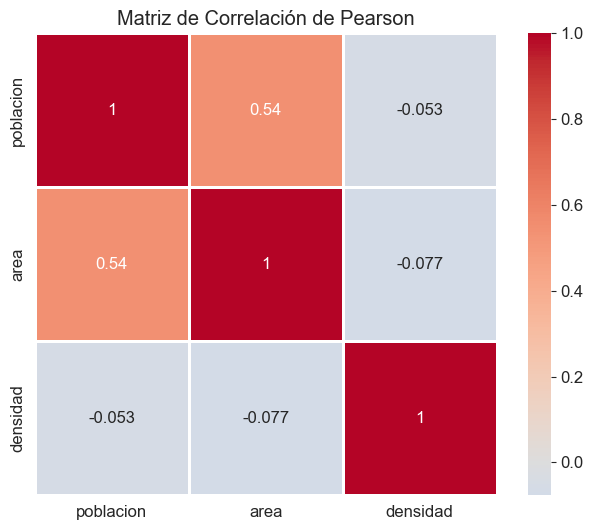

In [84]:
import pandas as pd
import seaborn as sns
df = pd.DataFrame({
    'poblacion': df_muestra_ordenada["population"],
    'area': df_muestra_ordenada["area"],
    'densidad': df_muestra_ordenada["density"]
    
})
# Calcular todas las correlaciones
corr_matrix = df.corr()

# Visualizacion

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Matriz de Correlación de Pearson')
plt.show()

#### Cálculo de la CORRELACIÓN DE SPEARMAN:

---

"Hemos decidido calcular Spearman además de Pearson porque los datos demográficos suelen presentar distribuciones asimétricas. Spearman,nos ofrece una visión más fiel de la tendencia global sin verse tan afectado por "outliers."

---


In [90]:
from scipy import stats

# 1. Calcular la matriz de correlación de Spearman usando Pandas
# corr_spearman = df.corr(method='spearman')
corr_spearman = df[["poblacion", "area", "densidad"]].corr(method='spearman')
print(corr_spearman)

# 2. Cálculo individual y condicional de interpretación (Ejemplo: Población vs Área)
rho, p_value_spearman = stats.spearmanr(df["poblacion"], df["area"])

print(f"Correlación de Spearman (rho): {rho:.4f}")
print(f"P-value_Spearman: {p_value_spearman:.4f}")


           poblacion      area  densidad
poblacion   1.000000  0.915988   0.02198
area        0.915988  1.000000  -0.32542
densidad    0.021980 -0.325420   1.00000
Correlación de Spearman (rho): 0.9160
P-value_Spearman: 0.0000


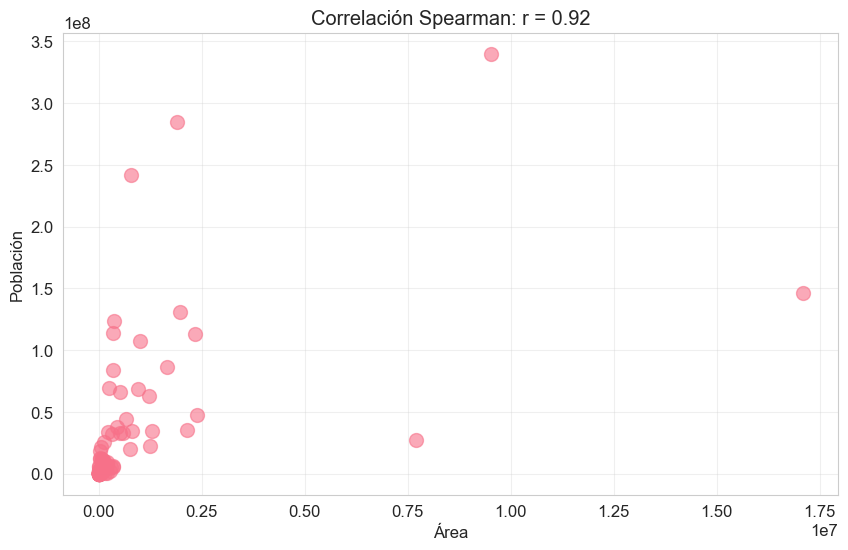

In [83]:
# Calcular Spearman solo entre dos variables para obtener r
rho, p_value = stats.spearmanr(df["area"], df["poblacion"])
    
plt.figure(figsize=(10, 6))
plt.scatter(df["area"], df["poblacion"], s=100, alpha=0.6)
plt.xlabel("Área")
plt.ylabel("Población")
plt.title(f"Correlación Spearman: r = {rho:.2f}")
plt.grid(True, alpha=0.3)
plt.show()

In [68]:
import matplotlib.pyplot as plt
import plotly.express as px

fig = px.scatter(
    df_muestra_ordenada,
    x="area",
    y="population",
    hover_name="country",   # nombre principal al pasar el mouse
    hover_data={
        "region": True,
        "density": True,
        "area": True,
        "population": True
    },
    title=(f"Correlación de spearman: rho = {rho:.4f}")
)
fig.show()
#fig.show(renderer="browser")

#### MATRIZ DE CORRELACIÓN DE SPEARMAN:
---

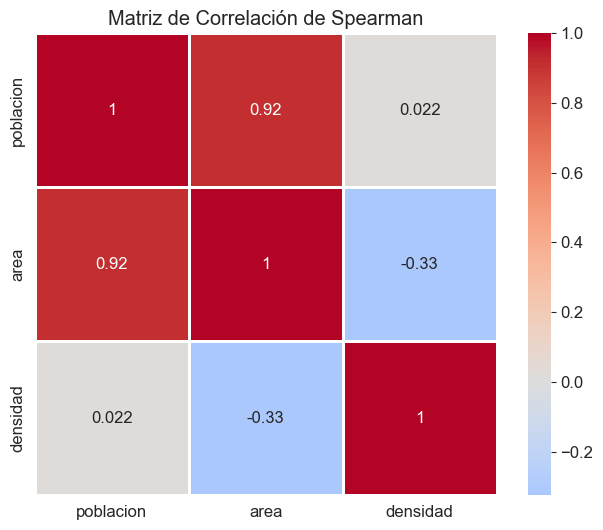

In [69]:
# 2. Visualizacion

plt.figure(figsize=(8, 6))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0, 
square=True, linewidths=1)
plt.title('Matriz de Correlación de Spearman')
plt.show()

#### REGRESION LINEAL SIMPLE:

---

La regresión lineal simple ayuda a hacer predicciones y a comprender las relaciones entre una variable independiente (área) y una variable dependiente(población).

![alt text](https://www.jacobsoft.com.mx/wp-content/uploads/2018/09/resumen-regresion-lineal.png)




In [81]:
# Regresión

# Nuestras variables
x = df_muestra_ordenada["area"]        # variable independiente
y = df_muestra_ordenada["population"]    # variable dependiente

from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f"Pendiente (β₁): {slope:.2f}")
print(f"Intercepto (β₀): {intercept:.2f}")
print(f"R²: {r_value**2:.2f}")
print(f"P-value: {p_value:.4f}")

# Ecuación
print(f"\nEcuación: y = {intercept:.2f} + {slope:.2f}*x")

Pendiente (β₁): 14.69
Intercepto (β₀): 18072356.91
R²: 0.30
P-value: 0.0000

Ecuación: y = 18072356.91 + 14.69*x


### ❓ ¿qué significa cada dato obtenido?

---

**Pendiente (β₁)**: 14.69 
Por cada km² adicional de área, la población aumenta de media 14.69 personas. Es decir, países más grandes tienden a tener más población.<br>

**Intercepto (β₀)**: 18072356.91   
Este número es solo un ajuste matemático para que la línea encaje con los países grandes. Es un indicador de que la relación no empieza exactamente en el origen (0,0).

**R²: 0.30**   
R² = r² → es el coeficiente de correlación de Pearson al cuadrado o también llamado *Bondad de ajuste* 

Explica el 30% de la variación en la población. Lo que implica que el 70% se explica por otros factores como historia, clima, economía...<br>
- **R² > 0.7:** Ajuste fuerte
- **0.4 < R² < 0.7:** Ajuste moderado
- **R² < 0.4:** Ajuste débil

**P-value**: 0.0000   
La relación es estadísticamente significativa ✅. No es casualidad.<br>



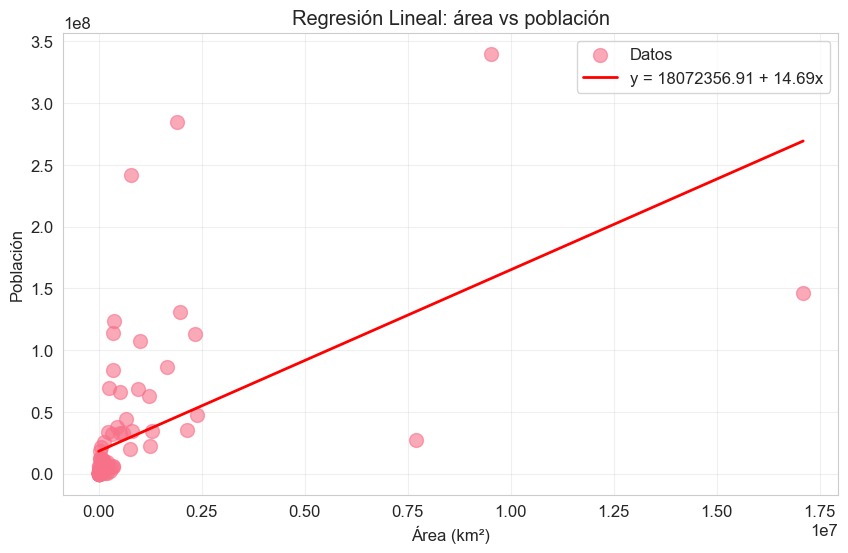

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Línea de regresión
x_line = np.linspace(min(df_muestra_ordenada["area"]), max(df_muestra_ordenada["area"]), 100)
y_line = intercept + slope * x_line

plt.figure(figsize=(10, 6))
plt.scatter(df_muestra_ordenada["area"], df_muestra_ordenada["population"], s=100, alpha=0.6, label='Datos')
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {intercept:.2f} + {slope:.2f}x')
plt.xlabel('Área (km²)')
plt.ylabel('Población')
plt.title('Regresión Lineal: área vs población')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### RESIDUOS: ERRORES DEL MODELO

---

$$ \text{Residuo} = y_{real} - y_{predicho} $$


Residuo es la diferencia entre el valor real y el valor que predice el modelo:   
residuo = población real - población que predice la recta   

- Residuo positivo → el modelo subestimó la población
- Residuo negativo → el modelo sobreestimó la población
- Residuo = 0 → predicción perfecta ✅   



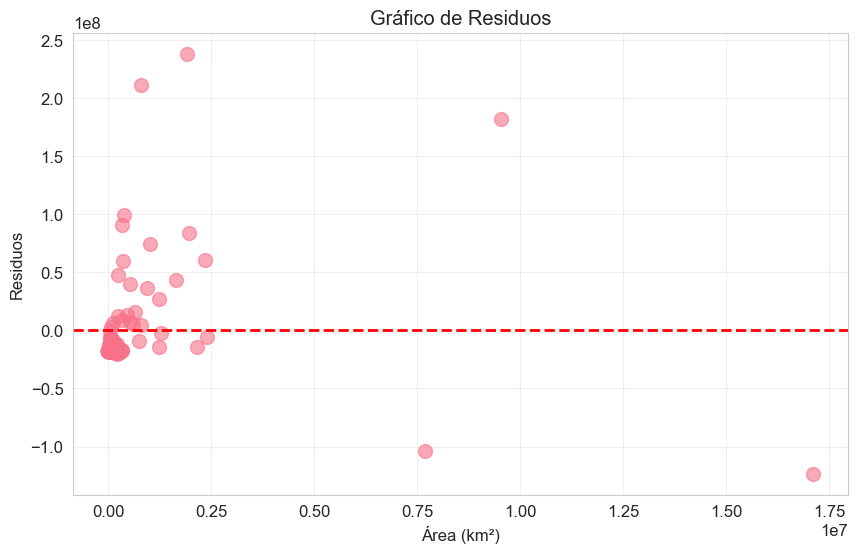

In [78]:
# Calcular predicciones
y_pred = intercept + slope * np.array(df_muestra_ordenada["area"])

# Calcular residuos
residuos = np.array(df_muestra_ordenada["population"]) - y_pred

# Visualizar
plt.figure(figsize=(10, 6))
plt.scatter(df_muestra_ordenada["area"], residuos, s=100, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Área (km²)')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')
plt.grid(True, alpha=0.3)
plt.show()

In [76]:
import pandas as pd
import numpy as np
import plotly.express as px
# Calcular predicciones
y_pred = intercept + slope * np.array(df_muestra_ordenada["area"])
# Calcular residuos
residuos = np.array(df_muestra_ordenada["population"]) - y_pred
# Crear dataframe para la gráfica
df_residuos = pd.DataFrame({
    "country": df_muestra_ordenada["country"].values,
    "region": df_muestra_ordenada["region"].values,
    "poblacion": df_muestra_ordenada["population"].values,  # <- desde el df
    "area": df_muestra_ordenada["area"].values,             # <- desde el df
    "y_pred": y_pred,
    "residuos": residuos
})
# Gráfico interactivo
fig = px.scatter(
    df_residuos,
    x="area",
    y="residuos",
    hover_name="country",
    hover_data={
        "region": True,
        "area": True,
        "y_pred": True,
        "residuos": True,
        "poblacion": True
    },
    title="Gráfico de Residuos"
)
fig.add_hline(y=0, line_dash="dash", line_color="red")
# fig.show(renderer="browser")
fig.show()

Nuestro modelo no está funcionando bien para predecir la población de países grandes, se aleja mucho de la línea de puntos.

### 📊 Interpretación del Resultado: 

### Conclusiones:

### Análisis de Correlación y Regresión (Población vs. Área)

1. <u>**Validación de la Relación:**</u>   

Se confirma una correlación positiva moderada ($r = 0.54$), que asciende a 0.91 al usar el coeficiente de Spearman(rho).
Esto demuestra que existe una tendencia clara de crecimiento conjunto, aunque la extensión territorial no es el único factor determinante de la población.
 
2. <u>**Limitaciones del Modelo Lineal:**</u>   

El análisis de residuos indica que un modelo lineal simple es insuficiente para realizar predicciones exactas. La alta variabilidad de los datos sugiere que la demografía depende de factores externos (geográficos, económicos y sociales) que el modelo actual no captura.

3. <u>**Impacto de Casos Atípicos (Outliers):**</u>    

Se identificaron desviaciones significativas en países con densidades extremas (grandes territorios despoblados o áreas pequeñas saturadas). Para un entorno real de trabajo, estos casos deben tratarse de forma independiente para no sesgar las proyecciones globales.



